# Chapter 33: Onshore Gas Processing Plant

This notebook models an onshore gas processing plant with **TEG dehydration**
and **multi-stage compression**. We investigate how TEG circulation rate affects
dry gas water content, and calculate compressor power for export compression.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch22_onshore_plant.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 33.1 Wet Gas Feed Specification

The feed gas arrives from a gathering network at moderate pressure and is
water-saturated. We model it using the SRK equation of state.

In [2]:
# Create wet gas fluid
wet_gas = jneqsim.thermo.system.SystemSrkEos(273.15 + 25.0, 60.0)
wet_gas.addComponent("methane", 0.82)
wet_gas.addComponent("ethane", 0.06)
wet_gas.addComponent("propane", 0.03)
wet_gas.addComponent("n-butane", 0.01)
wet_gas.addComponent("CO2", 0.02)
wet_gas.addComponent("nitrogen", 0.01)
wet_gas.addComponent("water", 0.05)
wet_gas.setMixingRule("classic")
wet_gas.setMultiPhaseCheck(True)

feed = jneqsim.process.equipment.stream.Stream("Wet Gas Feed", wet_gas)
feed.setFlowRate(100000.0, "kg/hr")
feed.setTemperature(25.0, "C")
feed.setPressure(60.0, "bara")
feed.run()
assert _physics.run(feed, 'calculation_cell_3:feed', candidate=False)

print(f"Feed gas temperature: {feed.getTemperature('C'):.1f} C")
print(f"Feed gas pressure: {feed.getPressure('bara'):.1f} bara")
print(f"Feed gas flow rate: {feed.getFlowRate('kg/hr'):.0f} kg/hr")


Feed gas temperature: 25.0 C
Feed gas pressure: 60.0 bara
Feed gas flow rate: 100000 kg/hr


## 33.2 TEG Dehydration Concept

Triethylene glycol (TEG) dehydration is the most common method for removing
water from natural gas. The wet gas contacts lean TEG in an **absorber column**;
the rich TEG is then **regenerated** by heating to drive off water.

The key design variable is the **TEG circulation rate** — higher rates give
drier gas but consume more energy.

We use NeqSim's `SimpleTEGAbsorber` to model this.

In [3]:
# CPA-based TEG dehydration with an inlet separator and explicit solvent stream.
teg_fluid = SystemSrkCPAstatoil(298.15, 60.0)
for name, fraction in [("methane",0.82),("ethane",0.06),("propane",0.03),("CO2",0.02),("water",0.05)]:
    teg_fluid.addComponent(name, fraction)
teg_fluid.setMixingRule(10)
teg_fluid.setMultiPhaseCheck(True)
teg_feed = Stream("Wet feed", teg_fluid)
teg_feed.setFlowRate(80000.0, "kg/hr")
inlet_separator = Separator("Free-water knockout", teg_feed)
teg_solvent_fluid = SystemSrkCPAstatoil(313.15, 60.0)
# 99.5 wt% TEG: convert the specified mass fractions to consistent mole amounts.
teg_solvent_fluid.addComponent("TEG", 0.995 / 150.174)
teg_solvent_fluid.addComponent("water", 0.005 / 18.01528)
teg_solvent_fluid.setMixingRule(10)
teg_solvent = Stream("Lean TEG", teg_solvent_fluid)
teg_solvent.setFlowRate(1500.0, "kg/hr")
absorber = jneqsim.process.equipment.absorber.SimpleTEGAbsorber("TEG absorber")
absorber.addGasInStream(inlet_separator.getGasOutStream())
absorber.addSolventInStream(teg_solvent)
absorber.setNumberOfStages(5)
absorber.setStageEfficiency(0.7)
from teg_energy_reconstruction import close_teg_energy
teg_energy_corrections = []
process_teg = ProcessSystem()
for unit in [teg_feed, inlet_separator, teg_solvent, absorber]: process_teg.add(unit)
process_teg.run()
teg_energy_corrections.append(close_teg_energy(absorber, _physics))
assert _physics.run(process_teg, 'calculation_cell_5:process_teg', candidate=False)
dry_gas = absorber.getGasOutStream()
print(f"Wet gas to contactor: {inlet_separator.getGasOutStream().getFlowRate('kg/hr'):.2f} kg/hr; dry outlet {dry_gas.getTemperature('C'):.2f} C")


TEG energy reconstruction: {'raw_energy_residual_W': -3948.9017090671696, 'raw_relative_energy_residual': -0.0062966185368816974, 'native_temperature_K': 298.91867170982243, 'reconstructed_temperature_K': 298.9897744647318, 'temperature_shift_K': 0.07110275490936147, 'corrected_energy_residual_W': 2.1490268409252167e-07, 'limitation': 'Fixed-inventory energy closure of a Kremser approximation; no multistage equilibrium validation.'}
Wet gas to contactor: 76050.72 kg/hr; dry outlet 25.84 C


## 33.3 Effect of TEG Circulation Rate on Water Content

We vary the TEG lean flow rate and observe the resulting dry gas water content.
This is the classic dehydration design curve.

In [4]:
# Every circulation-rate point re-runs the complete NeqSim CPA absorber model.
teg_rates = np.linspace(500, 5000, 12)
water_content = []
for rate in teg_rates:
    teg_solvent.setFlowRate(float(rate), "kg/hr")
    process_teg.run()
    teg_energy_corrections.append(close_teg_energy(absorber, _physics))
    assert _physics.run(process_teg, 'calculation_cell_7:process_teg', candidate=False)
    dry_gas = absorber.getGasOutStream()
    water_content.append(float(dry_gas.getFluid().getPhase("gas").getComponent("water").getx()) * 1e6)
water_content = np.asarray(water_content)
assert np.all(np.isfinite(water_content)) and np.all(water_content >= 0)
pipeline_spec = 30.0  # ppmv; illustrative screening target, not a universal contract
print("TEG flow (kg/hr) | NeqSim dry-gas water (ppmv) | at or below 30 ppmv")
for rate, value in zip(teg_rates, water_content):
    print(f"{rate:15.1f} | {value:26.3f} | {value <= pipeline_spec}")


TEG energy reconstruction: {'raw_energy_residual_W': -8055.25310625456, 'raw_relative_energy_residual': -0.016610290425924525, 'native_temperature_K': 298.66216092552327, 'reconstructed_temperature_K': 298.80875986207155, 'temperature_shift_K': 0.14659893654828693, 'corrected_energy_residual_W': 2.3603206500411034e-07, 'limitation': 'Fixed-inventory energy closure of a Kremser approximation; no multistage equilibrium validation.'}
TEG energy reconstruction: {'raw_energy_residual_W': -5716.178556538303, 'raw_relative_energy_residual': -0.010537407601942196, 'native_temperature_K': 298.78645946794313, 'reconstructed_temperature_K': 298.89003607605054, 'temperature_shift_K': 0.10357660810740299, 'corrected_energy_residual_W': 2.234010025858879e-07, 'limitation': 'Fixed-inventory energy closure of a Kremser approximation; no multistage equilibrium validation.'}
TEG energy reconstruction: {'raw_energy_residual_W': -4365.510861571529, 'raw_relative_energy_residual': -0.007264185972969558, 'n

Figure saved to ../figures/ch22_teg_water_content.png


ch22_onshore_plant.ipynb:cell8:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


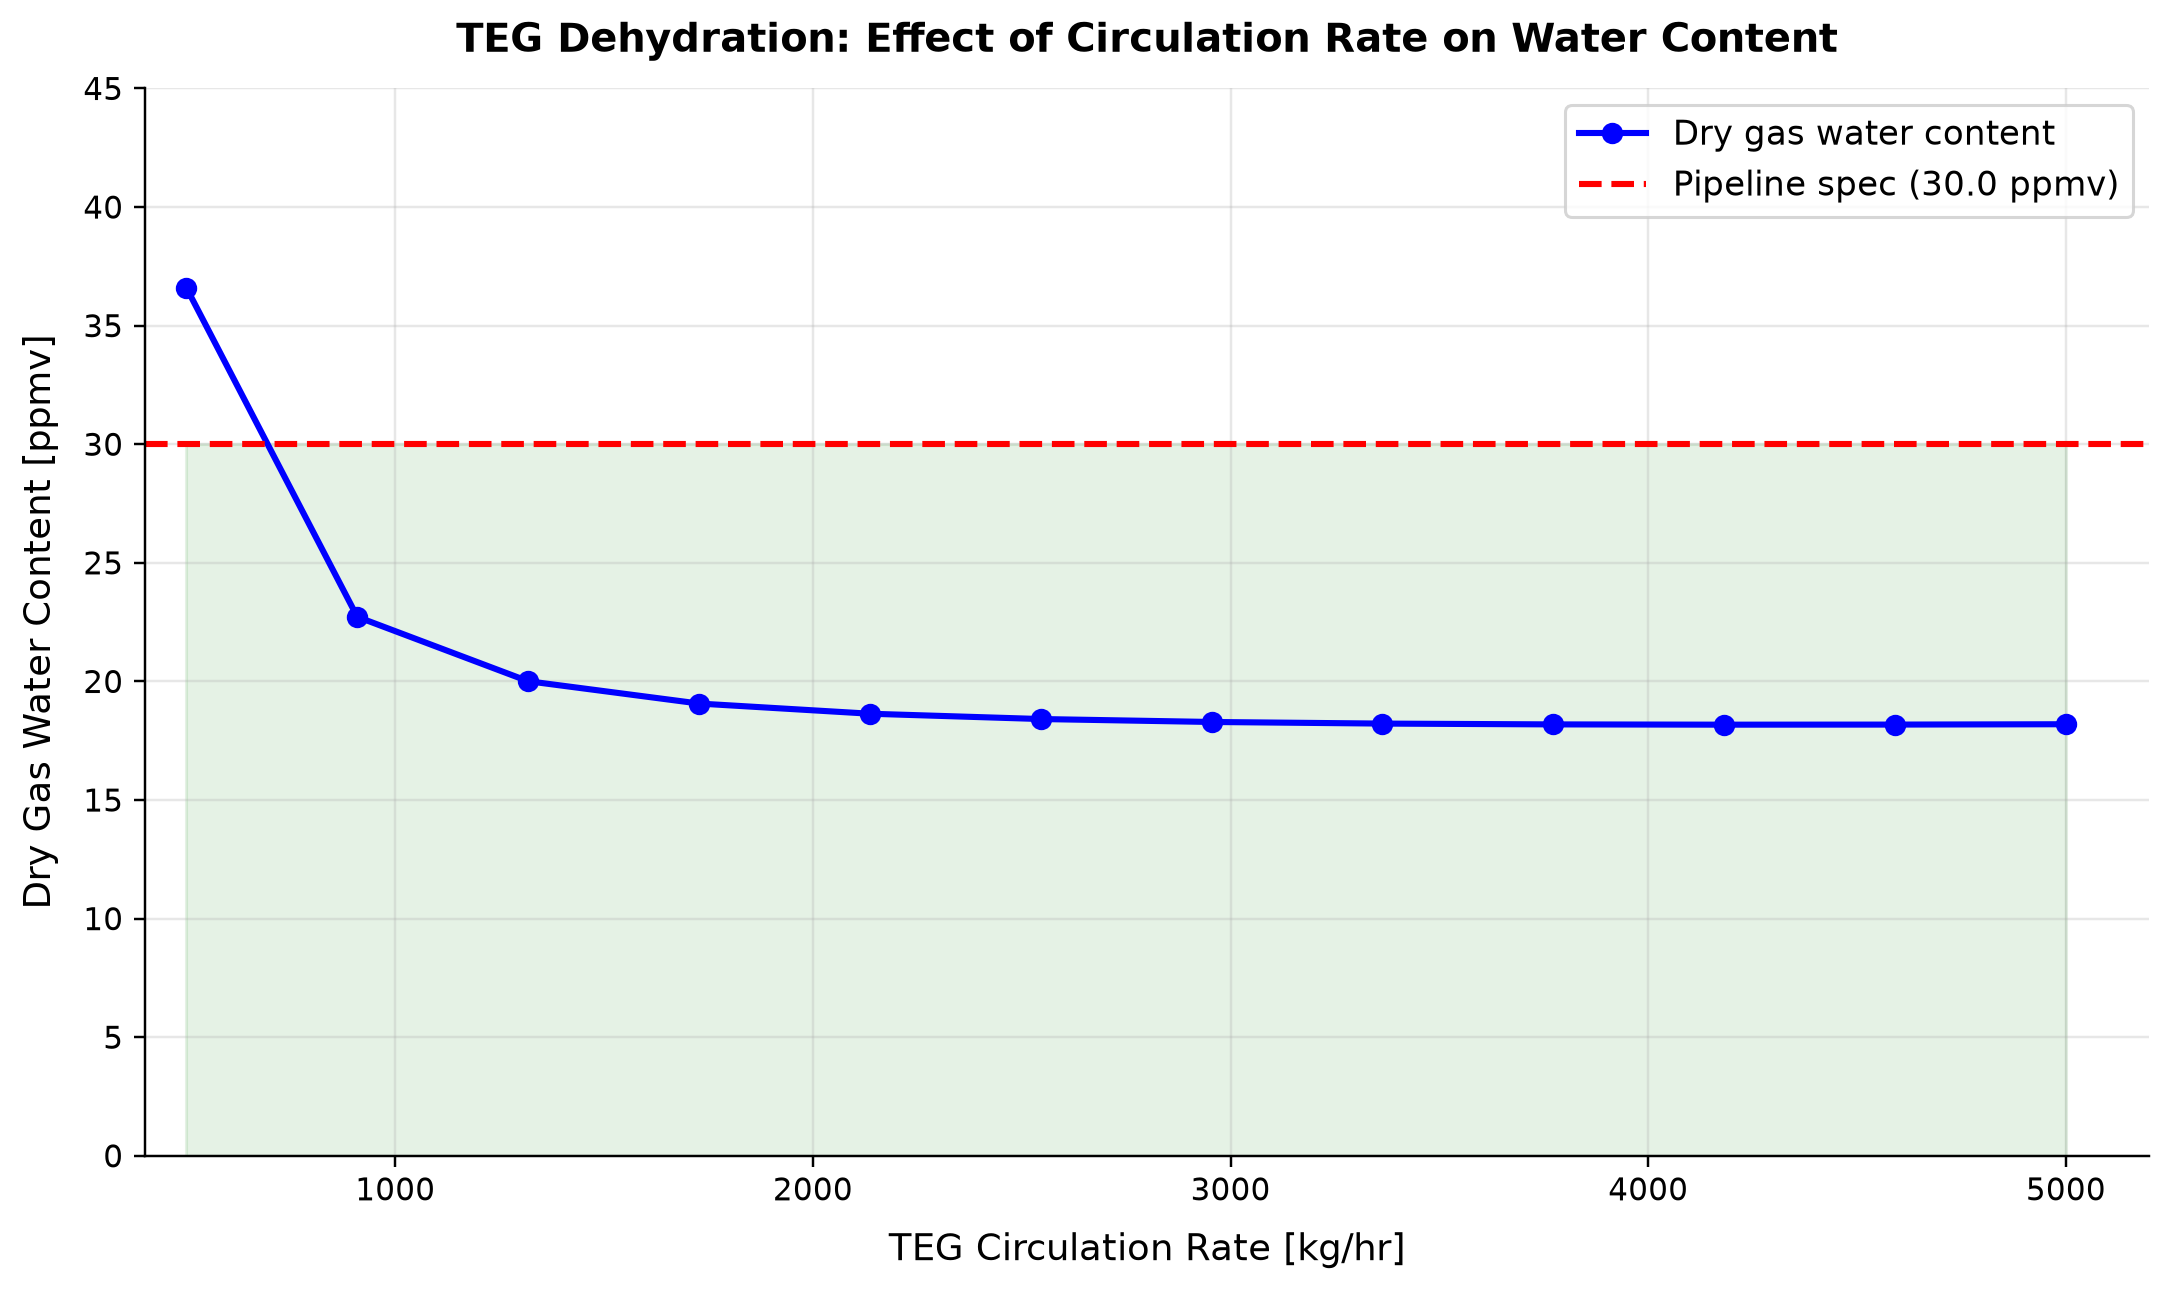

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(teg_rates, water_content, 'b-o', linewidth=2, markersize=6, label='Dry gas water content')
ax.axhline(y=pipeline_spec, color='red', linestyle='--', linewidth=2, label=f'Pipeline spec ({pipeline_spec} ppmv)')
ax.fill_between(teg_rates, 0, pipeline_spec, alpha=0.1, color='green')

ax.set_xlabel('TEG Circulation Rate [kg/hr]', fontsize=12)
ax.set_ylabel('Dry Gas Water Content [ppmv]', fontsize=12)
ax.set_title('TEG Dehydration: Effect of Circulation Rate on Water Content', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(45.0, float(max(water_content)) * 1.2))
ax.set_xlim(400, 5200)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch22_teg_water_content.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch22_teg_water_content.png")


**Executed-figure discussion.** Dry-gas water decreases from 36.596 ppmv at 500 kg/hr circulation to a sampled minimum of 18.177 ppmv at 4181.8 kg/hr, then rises slightly to 18.195 ppmv at 5000 kg/hr. All reconstructed cases retain explicit material and energy checks.

The CPA/Kremser approximation is rerun at each circulation rate, then a common outlet temperature closes the adiabatic energy balance while preserving its predicted component inventories. The 40 °C lean solvent is warmer than the 25 °C gas, so additional circulation combines increased absorption with sensible heating. The shallow minimum shows that more solvent does not guarantee a monotonically lower water content; the native contacting approximation is not a rigorous multistage energy model. Use the minimum as a screening observation, verify lean-solvent purity and thermal conditions, and calibrate contacting performance before selecting a field circulation rate.


## 33.4 Multi-Stage Export Compression

After dehydration, the gas is compressed to export pipeline pressure (e.g., 150 bara)
using a two-stage compressor with intercooling. We use NeqSim to calculate
compressor power at various discharge pressures.

In [6]:
# Multi-stage compression model
comp_fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 30.0, 60.0)
comp_fluid.addComponent("methane", 0.88)
comp_fluid.addComponent("ethane", 0.06)
comp_fluid.addComponent("propane", 0.03)
comp_fluid.addComponent("CO2", 0.02)
comp_fluid.addComponent("nitrogen", 0.01)
comp_fluid.setMixingRule("classic")

discharge_pressures = [80.0, 100.0, 120.0, 150.0, 180.0, 200.0]
total_powers = []

for p_out in discharge_pressures:
    # Interstage pressure (geometric mean)
    p_inter = np.sqrt(60.0 * p_out)

    comp_feed = jneqsim.process.equipment.stream.Stream("Comp Feed", comp_fluid.clone())
    comp_feed.setFlowRate(80000.0, "kg/hr")
    comp_feed.setTemperature(30.0, "C")
    comp_feed.setPressure(60.0, "bara")

    stage1 = jneqsim.process.equipment.compressor.Compressor("Stage 1", comp_feed)
    stage1.setOutletPressure(p_inter)

    intercooler = jneqsim.process.equipment.heatexchanger.Cooler("Intercooler", stage1.getOutletStream())
    intercooler.setOutTemperature(273.15 + 35.0)

    stage2 = jneqsim.process.equipment.compressor.Compressor("Stage 2", intercooler.getOutletStream())
    stage2.setOutletPressure(p_out)

    proc = jneqsim.process.processmodel.ProcessSystem()
    proc.add(comp_feed)
    proc.add(stage1)
    proc.add(intercooler)
    proc.add(stage2)
    proc.run()
    assert _physics.run(proc, 'calculation_cell_10:proc', candidate=False)

    total_power = stage1.getPower('kW') + stage2.getPower('kW')
    total_powers.append(total_power)
    print(f"Export P = {p_out:.0f} bara: Stage1 = {stage1.getPower('kW'):.0f} kW, "
          f"Stage2 = {stage2.getPower('kW'):.0f} kW, Total = {total_power:.0f} kW")


Export P = 80 bara: Stage1 = 395 kW, Stage2 = 400 kW, Total = 795 kW
Export P = 100 bara: Stage1 = 713 kW, Stage2 = 714 kW, Total = 1427 kW
Export P = 120 bara: Stage1 = 980 kW, Stage2 = 974 kW, Total = 1955 kW
Export P = 150 bara: Stage1 = 1317 kW, Stage2 = 1303 kW, Total = 2619 kW
Export P = 180 bara: Stage1 = 1600 kW, Stage2 = 1582 kW, Total = 3182 kW
Export P = 200 bara: Stage1 = 1767 kW, Stage2 = 1750 kW, Total = 3517 kW


Figure saved to ../figures/ch22_compression_power.png


ch22_onshore_plant.ipynb:cell11:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


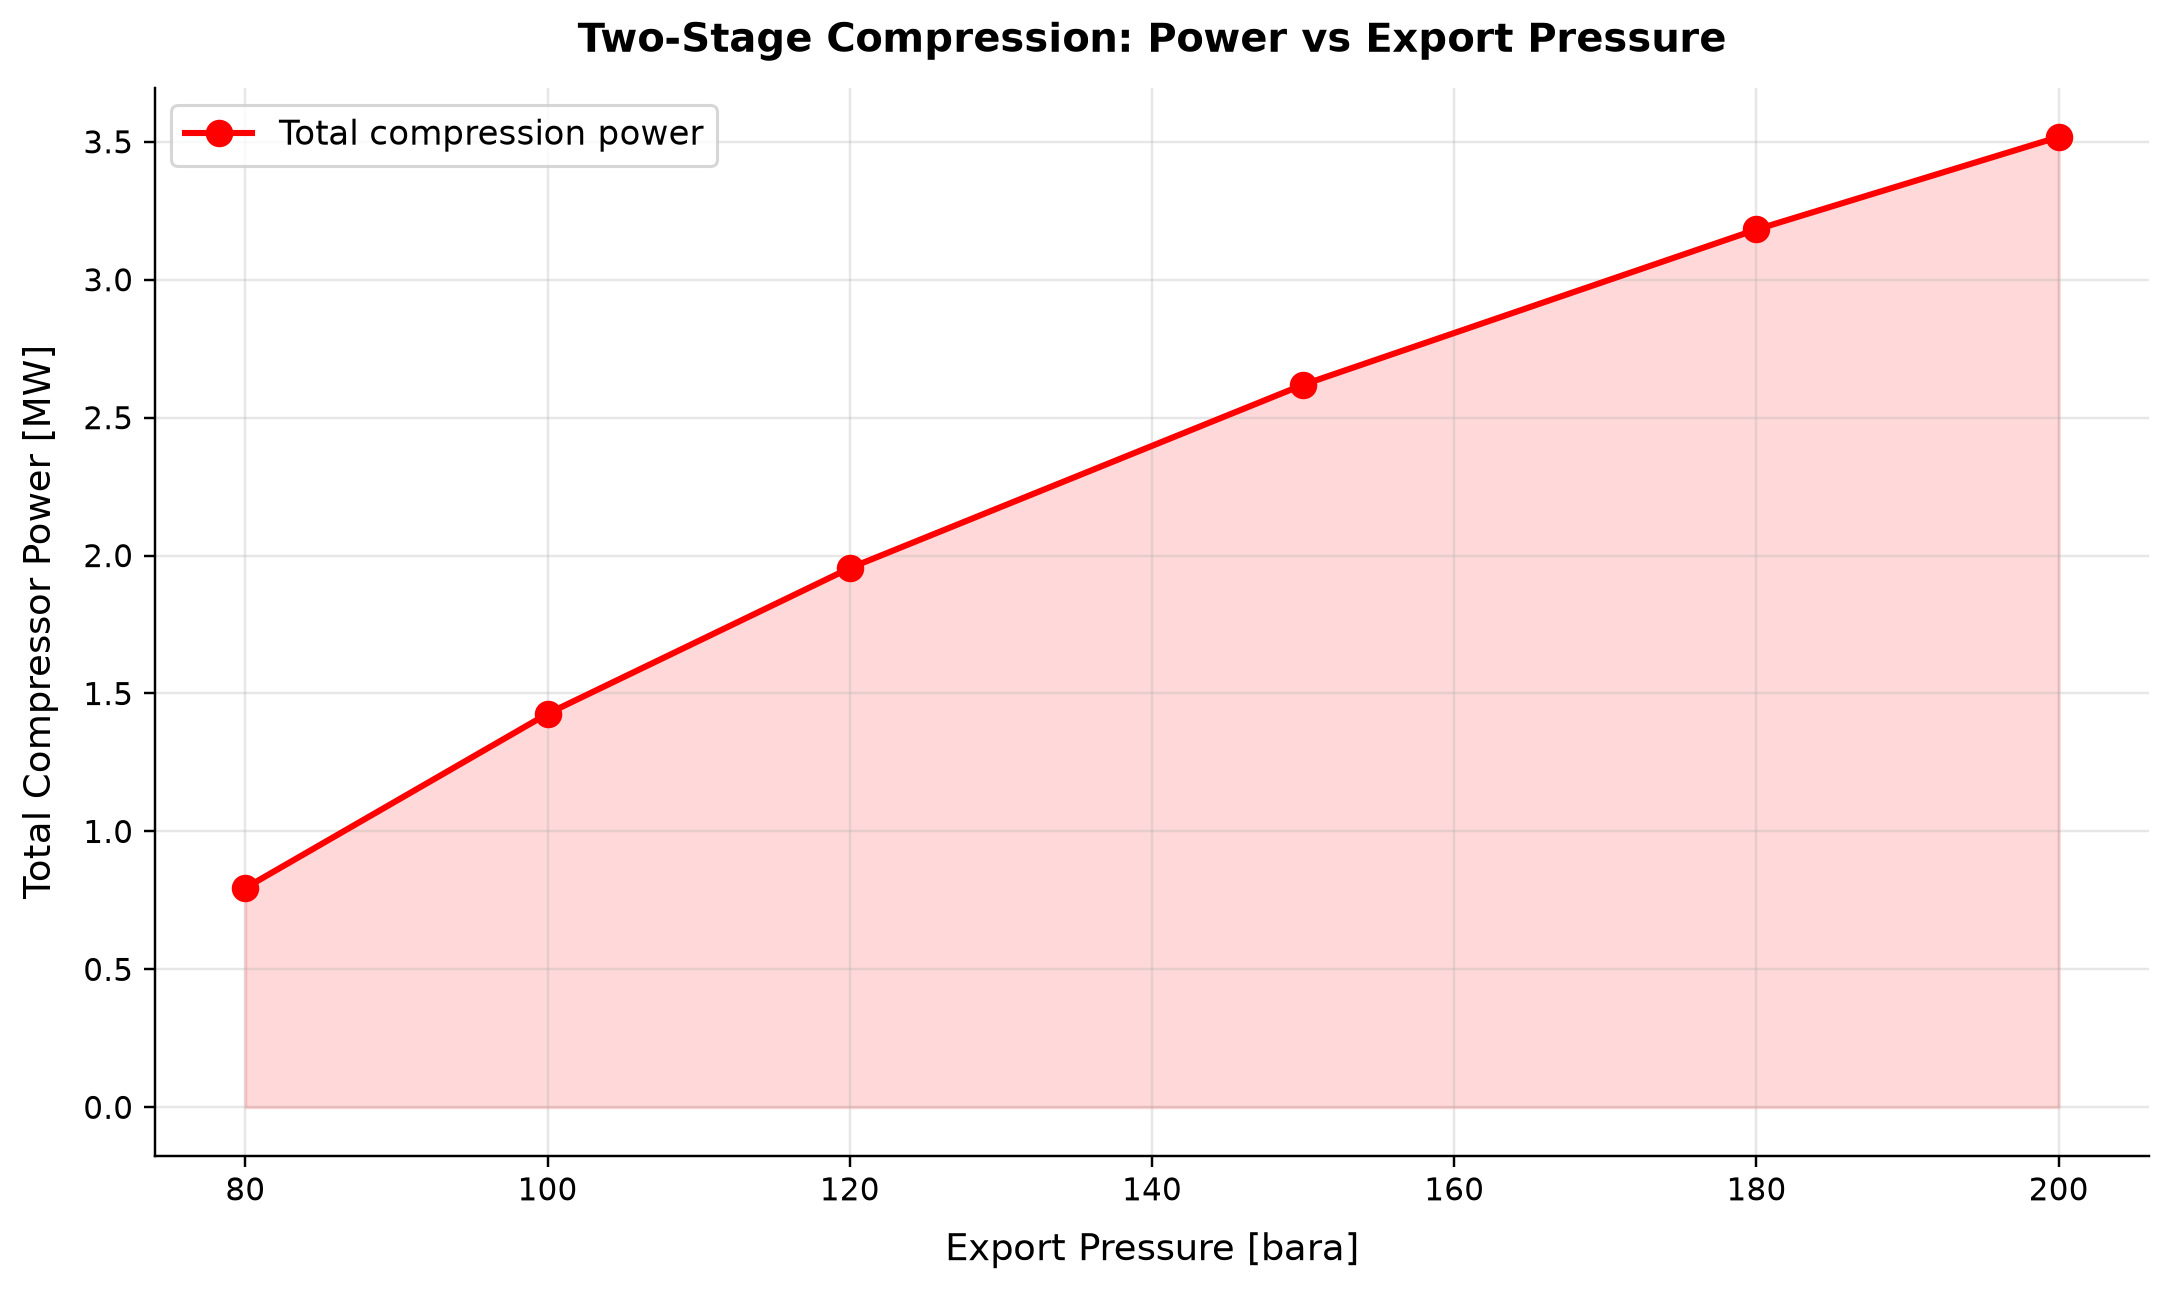

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(discharge_pressures, [p / 1000 for p in total_powers], 'ro-', linewidth=2, markersize=8,
        label='Total compression power')
ax.fill_between(discharge_pressures, 0, [p / 1000 for p in total_powers], alpha=0.15, color='red')

ax.set_xlabel('Export Pressure [bara]', fontsize=12)
ax.set_ylabel('Total Compressor Power [MW]', fontsize=12)
ax.set_title('Two-Stage Compression: Power vs Export Pressure', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch22_compression_power.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved to ../figures/ch22_compression_power.png")


**Executed-figure discussion.** Total compression power: total compressor power spans 0.795–3.517 MW across the plotted cases.

The two-stage train raises the discharge pressure while recalculating each stage and intercooling step. A higher export-pressure requirement directly raises compression demand. Include the export pipeline boundary and driver power allowance in the pressure selection.


## 33.5 Summary

**Key takeaways:**

1. **TEG dehydration** removes water from natural gas to meet pipeline specifications.
2. Higher TEG circulation rates give drier gas, but with **diminishing returns** beyond the optimal rate.
3. **Multi-stage compression** with intercooling is energy-efficient for high compression ratios.
4. Compressor power increases **non-linearly** with export pressure — critical for plant economics.
5. NeqSim enables rapid parametric studies of both dehydration and compression design.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [8]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                    Figure  Panel                    Series                Output / unit  Minimum  Maximum  Finite points  Missing points
ch22_teg_water_content.png      1     Dry gas water content Dry Gas Water Content [ppmv]  18.1767  36.5959             12               0
ch22_teg_water_content.png      1 Pipeline spec (30.0 ppmv) Dry Gas Water Content [ppmv]       30       30              2               0
ch22_compression_power.png      1   Total compression power  Total Compressor Power [MW] 0.795041  3.51748              6               0


## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [9]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 411 distinct checks, 2709 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

TEG material balance, explicit energy reconstruction and compression. Native SimpleTEGAbsorber has an energy residual after water transfer; reconstructed outlets close energy without validating stage mass transfer.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
